# ZQE with Gaussian MAP Encoder — Generic h(Y)

Implements the **ZQE estimator** for a Poisson GLLVM where the sufficient
statistic `h(Y)` is selectable independently for:

- **Encoder**: closed-form Gaussian MAP  
  `z_hat(y) = (W^T W + λI)^{-1} W^T (h_enc(y) - b)`
- **Decoder**: ZQE cross-term  
  `ℒ = E[h_dec(y)·η(ẑ(y))] − E_θ[h_dec(y_sim)·η(ẑ(y_sim))]`

Decoder parameters `(W, b)` are optimised with **SGD**.

> Same algorithm as `simulation_sparse/exp_A_sparse_loadings.ipynb` but with
> h(Y) fully configurable for both encoder and decoder.

## 1. Imports and Configuration

In [61]:
%load_ext autoreload
%autoreload 2

import os, random, copy, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim.swa_utils import AveragedModel
from scipy.spatial import procrustes as scipy_procrustes

from gllvm.simulations import make_sparse, simulate

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── experiment config ─────────────────────────────────────────────────────────
NL   = 1       # total latent dimensions
NR   = 100     # number of responses
NS   = 500     # number of observations
WZS  = .5     # loading scale
RPL  = NR // 1# responses_per_latent for TRUE model → 50% sparsity per column
               # fitted model is DENSE (does not know the mask)

# optimiser config
EPOCHS     = 500
LR_INIT    = 1.0
FLAT_FRAC  = 0.2
RM_ALPHA   = 0.9
RM_A       = 2.0
BATCH_SIZE = NS
N_MC       = 4
# Centering-term sim budget.
# The real term is deterministic (full batch, same data every epoch → zero variance).
# ALL gradient noise comes from the centering draw, so more sim samples are cheap
# and directly reduce variance.  We draw at least N_SIM_MIN per step — all under
# no_grad.  10× NS = 2000 shrinks centering std by √10 ≈ 3× at negligible cost.
N_SIM_MIN  = max(N_MC * NS * 10, 2000)   # 2000 for NS=200
EMA_DECAY  = 0.95
EMA_START  = 20
RIDGE      = 1.0
# L1_LAMBDA: proximal threshold = L1_LAMBDA × lr_now (lr-scaled ISTA).
# Fully LR-aware: changing LR_INIT / RM_ALPHA / RM_A scales lr_now proportionally,
# so L1_LAMBDA remains the single true regularisation knob.
# During flat phase (lr=1.0): thresh=L1_LAMBDA.
# At end of training (lr≈0.035): thresh=L1_LAMBDA×0.035.
L1_LAMBDA  = 0.005
SMOOTH     = 1     # for plotting


print(f"device={device}  NL={NL}  NR={NR}  NS={NS}  RPL={RPL} (true 50% sparse)")
print(f"L1_LAMBDA={L1_LAMBDA}  N_SIM_MIN={N_SIM_MIN}  (prox-L1 ISTA, threshold = λ × lr)")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device=cuda  NL=1  NR=100  NS=500  RPL=100 (true 50% sparse)
L1_LAMBDA=0.005  N_SIM_MIN=20000  (prox-L1 ISTA, threshold = λ × lr)


## 2. Data Generation

In [62]:
torch.manual_seed(SEED)

# ── TRUE model: sparse W via responses_per_latent mask ───────────────────────
# Each active latent column connects to only RPL out of NR responses.
# The FITTED model will NOT know this mask — it starts dense.
g0 = make_sparse(
    n_latent=NL,
    poisson=NR,
    active_latent=NL,          # all dims active
    wz_scale=WZS,
    responses_per_latent=RPL,  # ← sparse true model (50% nnz per column)
).to(device)

y_all, z_all = simulate(g0, n_samples=NS, device=device)

W_true_np = g0.wz.detach().cpu().numpy()   # (NR, NL)
true_nnz  = [(g0.wz[:, q] != 0).sum().item() for q in range(NL)]
true_zero = NR * NL - sum(true_nnz)

print(f"y shape: {y_all.shape}   mean count: {y_all.float().mean():.2f}   "
      f"sparsity: {(y_all == 0).float().mean():.2%}")
print(f"W_true: {g0.wz.shape}   nnz per column: {true_nnz}")
print(f"Total W entries: {NR*NL}   truly zero: {true_zero} ({100*true_zero/(NR*NL):.0f}%)")

y shape: torch.Size([500, 100])   mean count: 1.78   sparsity: 34.24%
W_true: torch.Size([100, 1])   nnz per column: [100]
Total W entries: 100   truly zero: 0 (0%)


## 3. h(Y) Transformation Registry

Each transform can be selected independently for encoder and decoder.
All functions accept a float tensor and return a float tensor of the same shape.

In [63]:
H_REGISTRY = {
    # canonical Poisson sufficient statistic
    "identity": lambda y: y.float(),

    # variance-stabilising / numerically stable transforms
    "log1p":    lambda y: torch.log1p(y.float()),
    "sqrt":     lambda y: torch.sqrt(y.float().clamp_min(0.0)),
    "anscombe": lambda y: 2.0 * torch.sqrt(y.float().clamp_min(0.0) + 3.0 / 8.0),

    # combinations (equal-weight averages)
    "log1p+sqrt":     lambda y: (torch.log1p(y.float()) + torch.sqrt(y.float().clamp_min(0.0))) / 2.0,
    "log1p+anscombe": lambda y: (torch.log1p(y.float()) +
                                 2.0 * torch.sqrt(y.float().clamp_min(0.0) + 3.0 / 8.0)) / 2.0,
}


def get_h(name: str):
    """Return the h function by name, with a clear error if unknown."""
    if name not in H_REGISTRY:
        raise ValueError(f"Unknown h: {name!r}. Choose from {list(H_REGISTRY)}")
    return H_REGISTRY[name]


# quick sanity check
_y_test = torch.tensor([0.0, 1.0, 4.0, 9.0])
print("h(Y) values on [0, 1, 4, 9]:")
for name, fn in H_REGISTRY.items():
    print(f"  {name:<20}: {fn(_y_test).numpy().round(3).tolist()}")


h(Y) values on [0, 1, 4, 9]:
  identity            : [0.0, 1.0, 4.0, 9.0]
  log1p               : [0.0, 0.6930000185966492, 1.6089999675750732, 2.302999973297119]
  sqrt                : [0.0, 1.0, 2.0, 3.0]
  anscombe            : [1.225000023841858, 2.3450000286102295, 4.183000087738037, 6.124000072479248]
  log1p+sqrt          : [0.0, 0.847000002861023, 1.8049999475479126, 2.6510000228881836]
  log1p+anscombe      : [0.6119999885559082, 1.5190000534057617, 2.8959999084472656, 4.2129998207092285]


## 4. Gaussian MAP Encoder

Closed-form solution assuming `h_enc(y) | z ~ N(Wz + b, σ²I)` with prior `z ~ N(0, I)`:

$$\hat{z}(y;\, W,b) = (W^\top W + \lambda I_Q)^{-1}\, W^\top\,\bigl(h_\text{enc}(y) - b\bigr)$$

where `λ = σ²` (ridge = 1 by default, matching the N(0,I) prior).
No learnable parameters. Recomputes the Cholesky every call so it tracks W as it evolves.

In [64]:
class GaussianMAPEncoder(nn.Module):
    """
    Parameter-free Gaussian MAP encoder with selectable h_enc.

    Assumes proxy model:
        h_enc(y) | z  ~  N(W z + b,  ridge * I_P)
        z             ~  N(0, I_Q)

    Closed-form MAP:
        z_hat(y) = (W^T W + ridge * I_Q)^{-1} W^T (h_enc(y) - b)

    Parameters
    ----------
    gllvm   : GLLVM module (provides .wz [P, Q] and .bias [P])
    h_enc   : str or callable — transformation applied to y before solving
    ridge   : float — σ² / prior precision ratio (default 1.0)
    """

    def __init__(self, gllvm, h_enc="log1p", ridge: float = 1.0):
        super().__init__()
        self.gllvm = gllvm
        self.h_fn  = get_h(h_enc) if isinstance(h_enc, str) else h_enc
        self.ridge = ridge

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        """
        y : [N, P]  — raw counts
        returns z_hat : [N, Q]
        """
        W = self.gllvm.wz           # [P, Q]
        b = (self.gllvm.bias
             if self.gllvm.bias is not None
             else torch.zeros(W.shape[0], device=W.device, dtype=W.dtype))

        hy = self.h_fn(y)           # [N, P]  — transformed
        rhs = (hy - b) @ W          # [N, Q]  = (h(y) - b)^T W

        A = self.ridge * torch.eye(W.shape[1], device=W.device, dtype=W.dtype) + W.T @ W  # [Q, Q]
        z_hat = torch.linalg.solve(A, rhs.T).T   # [N, Q]
        return z_hat

    def sample(self, y):
        """Drop-in for Encoder.sample() protocol."""
        z = self.forward(y)
        return z, z, torch.full_like(z, float("-inf"))

    def loss(self, y, gllvm=None, **kwargs):
        dummy = next(self.gllvm.parameters())
        return torch.zeros(1, device=dummy.device, requires_grad=True), 0.0


# ── quick shape check ─────────────────────────────────────────────────────────
with torch.no_grad():
    _enc_test = GaussianMAPEncoder(g0, h_enc="log1p", ridge=RIDGE)
    _z_test   = _enc_test.forward(y_all[:5])
    print(f"Encoder output shape: {_z_test.shape}  (expected [5, {NL}])")
    print(f"  z_hat[0] = {_z_test[0].cpu().numpy().round(4)}")


Encoder output shape: torch.Size([5, 1])  (expected [5, 1])
  z_hat[0] = [0.2709]


## 5. ZQE Loss

The ZQE cross-term objective with generic `h_dec`:

$$\mathcal{L}(W, b) =
  \underbrace{\frac{1}{N}\sum_{i=1}^N h_\text{dec}(y_i)^\top \eta(\hat{z}(y_i))}_{\text{real term}}
  -
  \underbrace{\frac{1}{M}\sum_{m=1}^M h_\text{dec}(y_m^\text{sim})^\top \eta(\hat{z}(y_m^\text{sim}))}_{\text{centering term}}$$

where `η(z) = Wz + b` is the linear predictor and `ẑ(y)` is the Gaussian MAP encoder.
Both `h_enc` (inside the encoder) and `h_dec` (in the cross-term) are configurable independently.

In [65]:
def zqe_loss(gllvm, encoder, h_dec_fn, y_real: torch.Tensor,
             y_sim: torch.Tensor) -> torch.Tensor:
    """
    Pure ZQE cross-term loss.

    z is a fixed imputation (no gradient through the encoder).
    Gradient flows only through W and b inside η(z) = Wz + b.
    L1 regularisation is applied *after* the gradient step via the
    proximal operator (soft-thresholding), NOT added to this loss.
    """
    with torch.no_grad():
        z_real = encoder.forward(y_real)    # [N, Q]  detached
        z_sim  = encoder.forward(y_sim)     # [M, Q]  detached

    eta_real = gllvm.forward(z_real)        # [N, P]
    eta_sim  = gllvm.forward(z_sim)         # [M, P]

    hy_real = h_dec_fn(y_real)              # [N, P]
    hy_sim  = h_dec_fn(y_sim)               # [M, P]

    real_term = (hy_real * eta_real).sum(dim=-1).mean()
    cent_term = (hy_sim  * eta_sim ).sum(dim=-1).mean()
    return -(real_term - cent_term)


print("zqe_loss defined ✓  (pure ZQE cross-term — L1 applied via proximal op)")


zqe_loss defined ✓  (pure ZQE cross-term — L1 applied via proximal op)


## 6. Training Utilities

Procrustes error, LR schedule, EMA, and the main `run_zqe` loop —
mirrors `exp_A_sparse_loadings` but with `h_enc` / `h_dec` as explicit arguments.

In [66]:
# ── Procrustes error ──────────────────────────────────────────────────────────

def _best_rotation(A, B):
    U, _, Vt = np.linalg.svd(A.T @ B)
    R1 = (U @ Vt).T
    D = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(A - B @ R1) <= np.linalg.norm(A - B @ R2) else R2


def procr(g_true, g_est):
    a = g_true.wz.detach().cpu().numpy()
    b = g_est.wz.detach().cpu().numpy()
    R = _best_rotation(a, b)
    return float(np.linalg.norm(a - b @ R) / np.linalg.norm(a))


def _svd_init_W(y: torch.Tensor, h_fn, Q: int, scale: float) -> torch.Tensor:
    """
    Warm-start W from the top-Q left singular vectors of h(Y).

    SVD of h(Y) gives the 'principal component' rotation — already approximately
    aligned with the true factor structure.  This puts us in a rotation where
    entries are heterogeneous (large in a few dims, near-zero in others), so the
    proximal operator finds zeros immediately rather than having to drift there
    from a uniformly dense initialisation.

    Returns W of shape [P, Q], columns scaled to ||w_j|| ≈ scale * √P.
    """
    with torch.no_grad():
        hy = h_fn(y).float()                    # [N, P]
        hy_c = hy - hy.mean(0, keepdim=True)    # centre columns
        U, S, Vh = torch.linalg.svd(hy_c, full_matrices=False)
        # Vh: [K, P],  K = min(N, P).  Take top Q rows → W = Vh[:Q].T  [P, Q]
        W_init = Vh[:Q].T                        # [P, Q]
        # Scale so each column has norm ≈ scale * √P  (matches random N(0, scale²) norm)
        col_norms = W_init.norm(dim=0, keepdim=True).clamp_min(1e-8)
        W_init = W_init / col_norms * (scale * math.sqrt(W_init.shape[0]))
    return W_init


# ── Robbins–Monro LR schedule ─────────────────────────────────────────────────

def _flat_rm_scheduler(opt, epochs, flat_frac=0.1, rm_alpha=0.6, rm_a=1.0):
    flat_ep = int(flat_frac * epochs)
    def lr_lambda(ep):
        if ep < flat_ep:
            return 1.0
        t = ep - flat_ep + 1
        return (rm_a / (rm_a + t)) ** rm_alpha
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


# ── Main training loop ────────────────────────────────────────────────────────

def run_zqe(g0_ref, h_enc: str, h_dec: str,
            label: str, colour: str,
            lr_init: float = LR_INIT,
            flat_frac: float = FLAT_FRAC,
            rm_alpha: float = RM_ALPHA,
            rm_a: float = RM_A,
            epochs: int = EPOCHS,
            n_mc: int = N_MC,
            n_sim_min: int = N_SIM_MIN,
            ridge: float = RIDGE,
            l1_lambda: float = 0.0,
            batch_size: int = BATCH_SIZE,
            ema_decay: float = EMA_DECAY,
            ema_start: int = EMA_START,
            svd_init: bool = False):      # ← warm-start W from SVD of h(Y)

    g = copy.deepcopy(g0_ref)
    g.set_wz_mask(torch.ones(g.p, g.q))

    h_enc_fn = get_h(h_enc)
    h_dec_fn = get_h(h_dec)

    with torch.no_grad():
        if svd_init:
            # SVD warm-start: puts W in the PC rotation — heterogeneous entries,
            # close to sparse, so prox finds zeros immediately.
            W0 = _svd_init_W(y_all, h_enc_fn, g.q, scale=WZS).to(g.wz.device)
            g.wz.copy_(W0)
        else:
            # Random init: isotropic, no rotation preference.
            # Prox has to drift to a sparse rotation via SGD noise + flat-phase.
            nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)

    encoder  = GaussianMAPEncoder(g, h_enc=h_enc_fn, ridge=ridge)
    opt       = torch.optim.SGD(list(g.parameters()), lr=lr_init)
    scheduler = _flat_rm_scheduler(opt, epochs, flat_frac=flat_frac,
                                   rm_alpha=rm_alpha, rm_a=rm_a)

    ema_fn    = lambda avg, cur, n: ema_decay * avg + (1 - ema_decay) * cur
    ema_model = AveragedModel(g, avg_fn=ema_fn)
    ema_active = False

    h_err, h_err_ema, h_loss = [], [], []

    init_str = "SVD" if svd_init else "random"
    print(f"\n[{label}]  h_enc={h_enc}  h_dec={h_dec}  l1={l1_lambda:.3g}"
          f"  lr={lr_init:.1e}  n_sim={n_sim_min}  init={init_str}"
          f"  start Proc={procr(g0_ref, g):.4f}")

    for ep in range(epochs):
        ep_loss, n_batches = 0.0, 0
        perm = torch.randperm(len(y_all), device=device)

        for i in range(0, len(y_all), batch_size):
            batch = y_all[perm[i: i + batch_size]]

            n_sim = max(n_mc * len(batch), n_sim_min)
            with torch.no_grad():
                z_q   = g.sample_z(n_sim)
                y_sim = g.sample(z=z_q)
            loss = zqe_loss(g, encoder, h_dec_fn, batch, y_sim)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(g.parameters()), 5.0)
            if not torch.isnan(loss):
                opt.step()
                # ── Proximal operator for L1 (ISTA):
                #   prox_{λ·lr·||·||_1}(w) = sign(w) * max(|w| - λ·lr, 0)
                # Threshold ∝ lr_now: large early (aggressive sparsification in PC
                # frame), small late (fine-tuning).  Self-reinforcing: zeroed entries
                # keep small gradients → stay zero.
                if l1_lambda > 0.0:
                    lr_now = opt.param_groups[0]["lr"]
                    thresh = l1_lambda * lr_now
                    with torch.no_grad():
                        g.wz.data = torch.sign(g.wz) * (g.wz.abs() - thresh).clamp_min(0.0)

            ep_loss   += loss.item()
            n_batches += 1

        scheduler.step()

        if ep >= ema_start:
            ema_model.update_parameters(g)
            ema_active = True

        h_err.append(procr(g0_ref, g))
        h_err_ema.append(procr(g0_ref, ema_model.module) if ema_active else h_err[-1])
        h_loss.append(ep_loss / n_batches)

        if (ep + 1) % max(1, epochs // 5) == 0:
            print(f"  ep {ep+1:4d}/{epochs}  loss={h_loss[-1]:+.4f}"
                  f"  Proc={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}"
                  f"  lr={opt.param_groups[0]['lr']:.2e}"
                  f"  zeros={int((g.wz == 0).sum())}")

    print(f"[{label}]  FINAL  raw={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}"
          f"  zeros={int((g.wz == 0).sum())}/{g.wz.numel()}")

    return {"err": h_err, "err_ema": h_err_ema, "loss": h_loss,
            "colour": colour, "label": label,
            "h_enc": h_enc, "h_dec": h_dec, "g": g}


print("run_zqe defined ✓  (svd_init option added)")


run_zqe defined ✓  (svd_init option added)


## 7. Run Experiments

Compare different choices of `(h_enc, h_dec)`.  
The first arm (`log1p / log1p`) reproduces the best arm from `simulation_sparse`.

In [67]:
# ── Experiment arms ──────────────────────────────────────────────────────────
# (h_enc, h_dec, label, colour, l1_lambda, svd_init)
# SVD init puts W in the PC rotation → heterogeneous entries → prox finds zeros fast.
# Random init relies on SGD noise to drift into a sparse rotation (slower, less reliable).
ARMS = [
    # ("log1p", "log1p", "random + no L1",  "tab:blue",   0.0,       False),
    ("log1p", "log1p", "random + prox-L1", "tab:orange", L1_LAMBDA, False),
    # ("log1p", "log1p", "SVD   + no L1",   "tab:green",  0.0,       True),
    # ("log1p", "log1p", "SVD   + prox-L1", "tab:red",    L1_LAMBDA, True),
]

results = {}
torch.manual_seed(SEED)

for h_enc, h_dec, label, colour, l1, svd in ARMS:
    res = run_zqe(g0, h_enc=h_enc, h_dec=h_dec, label=label, colour=colour,
                  l1_lambda=l1, svd_init=svd)
    results[label] = res



[random + prox-L1]  h_enc=log1p  h_dec=log1p  l1=0.005  lr=1.0e+00  n_sim=20000  init=random  start Proc=1.3730
  ep  100/500  loss=-0.2560  Proc=0.1331  EMA=0.1335  lr=6.94e-01  zeros=0
  ep  200/500  loss=-0.2036  Proc=0.1327  EMA=0.1326  lr=2.88e-02  zeros=1
  ep  300/500  loss=-0.1640  Proc=0.1324  EMA=0.1325  lr=1.56e-02  zeros=0
  ep  400/500  loss=-0.2262  Proc=0.1324  EMA=0.1324  lr=1.09e-02  zeros=1
  ep  500/500  loss=-0.1437  Proc=0.1325  EMA=0.1325  lr=8.44e-03  zeros=1
[random + prox-L1]  FINAL  raw=0.1325  EMA=0.1325  zeros=1/100


## 8. Results and Diagnostics

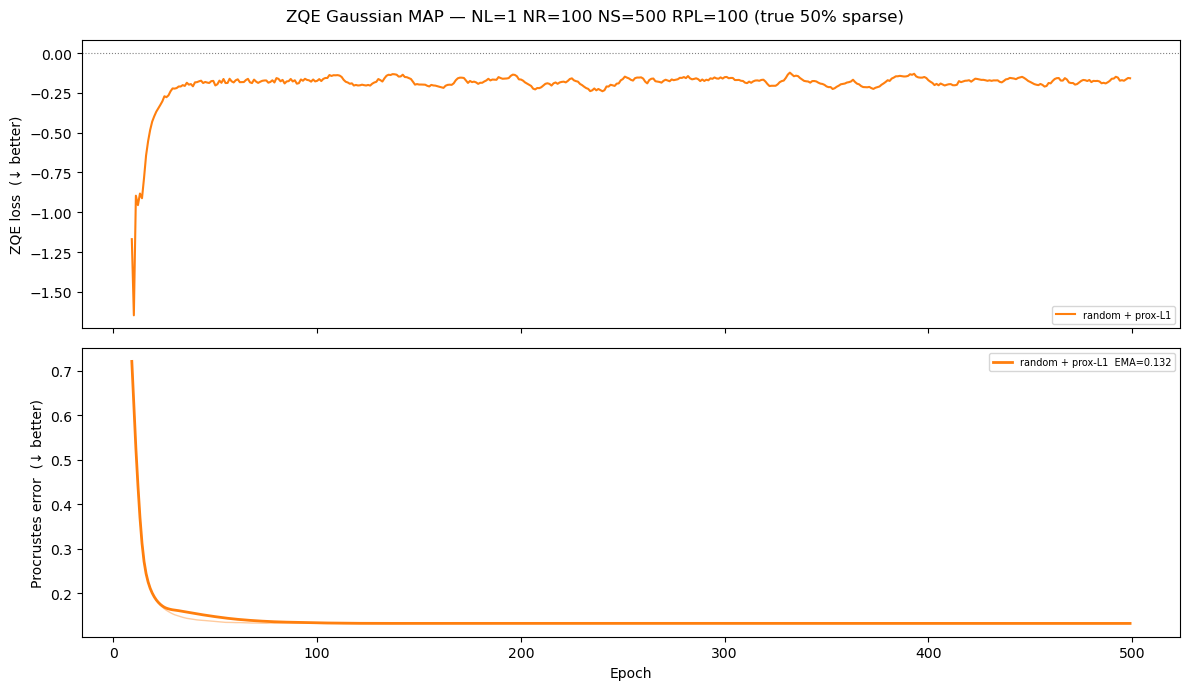


Arm                                         h_enc           h_dec               raw      EMA
──────────────────────────────────────────────────────────────────────────────────────────
random + prox-L1                            log1p           log1p            0.1325   0.1325


In [68]:
def smooth(x, w=10):
    if w <= 1:
        return np.array(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


SMOOTH = 10
xs = np.arange(SMOOTH - 1, EPOCHS)

fig, (ax_loss, ax_proc) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f"ZQE Gaussian MAP — NL={NL} NR={NR} NS={NS} RPL={RPL} (true 50% sparse)")

for label, res in results.items():
    col = res["colour"]
    ax_loss.plot(xs, smooth(res["loss"], SMOOTH),   color=col, lw=1.5, label=label)
    ax_proc.plot(xs, smooth(res["err"],  SMOOTH),   color=col, lw=1.0, alpha=0.4)
    ax_proc.plot(xs, smooth(res["err_ema"], SMOOTH), color=col, lw=2.0,
                 label=f"{label}  EMA={res['err_ema'][-1]:.3f}")

ax_loss.axhline(0, color="gray", ls=":", lw=0.8)
ax_loss.set_ylabel("ZQE loss  (↓ better)"); ax_loss.legend(fontsize=7)
ax_proc.set_ylabel("Procrustes error  (↓ better)"); ax_proc.legend(fontsize=7)
ax_proc.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Arm':<42}  {'h_enc':<14}  {'h_dec':<14}  {'raw':>7}  {'EMA':>7}")
print("─" * 90)
for label, res in sorted(results.items(), key=lambda kv: kv[1]["err_ema"][-1]):
    print(f"{label:<42}  {res['h_enc']:<14}  {res['h_dec']:<14}"
          f"  {res['err'][-1]:>7.4f}  {res['err_ema'][-1]:>7.4f}")


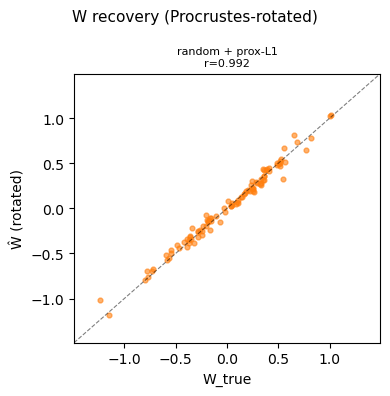

In [69]:
# ── W recovery scatter for each arm ──────────────────────────────────────────
n_arms = len(results)
fig2, axes = plt.subplots(1, n_arms, figsize=(4 * n_arms, 4))
if n_arms == 1:
    axes = [axes]

w_true = g0.wz.detach().cpu().numpy().ravel()

for ax, (label, res) in zip(axes, results.items()):
    w_est = res["g"].wz.detach().cpu().numpy()
    R = _best_rotation(g0.wz.detach().cpu().numpy(), w_est)
    w_rot = (w_est @ R).ravel()
    r = float(np.corrcoef(w_true, w_rot)[0, 1])
    ax.scatter(w_true, w_rot, s=12, alpha=0.6, color=res["colour"])
    lim = max(np.abs(w_true).max(), np.abs(w_rot).max()) * 1.2
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_title(f"{label}\nr={r:.3f}", fontsize=8)
    ax.set_xlabel("W_true"); ax.set_ylabel("Ŵ (rotated)")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

fig2.suptitle("W recovery (Procrustes-rotated)", fontsize=11)
plt.tight_layout(); plt.show()



True W sparsity: 0% zeros (0 / 100 entries)

  [random + prox-L1]  Proc=0.1325  ||W||_1=35.12  exact-zeros=1/100 (1%)
    EXACT-ZERO threshold  TP=99 FP=0 FN=1 TN=0  prec=1.00 rec=0.99 F1=0.99
    thresh p50=0.309  TP=50 FP=0 FN=50 TN=0  prec=1.00 rec=0.50 F1=0.67
    thresh p70=0.433  TP=30 FP=0 FN=70 TN=0  prec=1.00 rec=0.30 F1=0.46
    thresh p80=0.507  TP=20 FP=0 FN=80 TN=0  prec=1.00 rec=0.20 F1=0.33
    thresh p90=0.695  TP=10 FP=0 FN=90 TN=0  prec=1.00 rec=0.10 F1=0.18



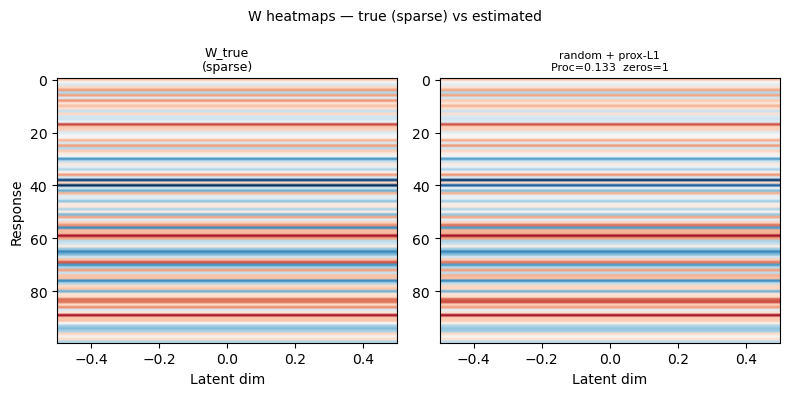

In [70]:

# ── Sparsity recovery diagnostics ────────────────────────────────────────────
# For each arm: threshold estimated W, compare to true zero/nonzero pattern.
# - "exact zero" counts entries that are numerically == 0 (proximal operator effect)
# - percentile thresholds as a fallback for the no-reg baseline

print(f"\nTrue W sparsity: {100*true_zero/(NR*NL):.0f}% zeros "
      f"({true_zero} / {NR*NL} entries)\n")

W_true_binary = (W_true_np != 0).astype(int)   # 1 = truly nonzero

for label, res in results.items():
    W_est = res["g"].wz.detach().cpu().numpy()  # (NR, NL)  raw, unrotated
    # Align to true W first via Procrustes rotation
    R = _best_rotation(W_true_np, W_est)
    W_rot = W_est @ R

    n_exact_zero = (W_est == 0.0).sum()
    print(f"  [{label}]  Proc={res['err'][-1]:.4f}  "
          f"||W||_1={np.abs(W_rot).sum():.2f}  "
          f"exact-zeros={n_exact_zero}/{NR*NL} ({100*n_exact_zero/(NR*NL):.0f}%)")

    # --- Exact-zero threshold (only meaningful when prox is used) ------------
    if n_exact_zero > 0:
        W_est_binary = (np.abs(W_rot) > 0.0).astype(int)
        tp = ((W_est_binary == 1) & (W_true_binary == 1)).sum()
        fp = ((W_est_binary == 1) & (W_true_binary == 0)).sum()
        fn = ((W_est_binary == 0) & (W_true_binary == 1)).sum()
        tn = ((W_est_binary == 0) & (W_true_binary == 0)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        print(f"    EXACT-ZERO threshold  TP={tp} FP={fp} FN={fn} TN={tn}"
              f"  prec={precision:.2f} rec={recall:.2f} F1={f1:.2f}")

    # --- Percentile thresholds -----------------------------------------------
    for pct in [50, 70, 80, 90]:
        thresh = np.percentile(np.abs(W_rot), pct)
        W_est_binary = (np.abs(W_rot) > thresh).astype(int)
        tp = ((W_est_binary == 1) & (W_true_binary == 1)).sum()
        fp = ((W_est_binary == 1) & (W_true_binary == 0)).sum()
        fn = ((W_est_binary == 0) & (W_true_binary == 1)).sum()
        tn = ((W_est_binary == 0) & (W_true_binary == 0)).sum()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        print(f"    thresh p{pct}={thresh:.3f}  TP={tp} FP={fp} FN={fn} TN={tn}"
              f"  prec={precision:.2f} rec={recall:.2f} F1={f1:.2f}")
    print()

# ── Visual: W heatmaps true vs estimated ─────────────────────────────────────
n_arms = len(results)
fig3, axes3 = plt.subplots(1, n_arms + 1, figsize=(4 * (n_arms + 1), 4))
vmax = np.abs(W_true_np).max()

axes3[0].imshow(W_true_np, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes3[0].set_title("W_true\n(sparse)", fontsize=9)
axes3[0].set_xlabel("Latent dim"); axes3[0].set_ylabel("Response")

for ax, (label, res) in zip(axes3[1:], results.items()):
    W_est = res["g"].wz.detach().cpu().numpy()
    R = _best_rotation(W_true_np, W_est)
    W_rot = W_est @ R
    n_exact = (W_est == 0.0).sum()
    ax.imshow(W_rot, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{label}\nProc={res['err'][-1]:.3f}  zeros={n_exact}", fontsize=8)
    ax.set_xlabel("Latent dim")

fig3.suptitle("W heatmaps — true (sparse) vs estimated", fontsize=10)
plt.tight_layout(); plt.show()
